In [18]:
import cv2
import csv
from collections import OrderedDict
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import sampler
from torch.utils.data import Dataset
import torchvision.datasets as dset
import torchvision.transforms as T
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import cv2
import mediapipe as mp
import os
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from concurrent.futures import ProcessPoolExecutor, as_completed
from concurrent.futures import ProcessPoolExecutor
import pickle
from IPython.display import display, Image, clear_output

In [3]:
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1, min_hand_detection_confidence=0.3)
detector = vision.HandLandmarker.create_from_options(options)

def get_dist_1d_vector(res):
    if not res.hand_landmarks:
        return None
    
    coords = np.array([[lm.x, lm.y, lm.z] for lm in res.hand_landmarks[0]])
    
    diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]
    dist_matrix = np.sqrt(np.sum(diff**2, axis=-1))
    
    palm_size = dist_matrix[0, 9]
    if palm_size > 0:
        dist_matrix = dist_matrix / palm_size
        
    return dist_matrix.flatten()

In [5]:
train_set = []

train_path = 'ASL_Dataset/Train/'


for i in range(0, 26):

    char = chr(ord('A') + i)
    
    if char in ['J', 'Z']:
        continue
    print(char)
    folder_path = train_path + char    
    for filename in os.listdir(folder_path):

        if filename.endswith(".jpg"):
            img_path = os.path.join(folder_path, filename)

            raw_img = cv2.imread(img_path)

            rgb_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

            upscaled = cv2.resize(rgb_img, (256, 256), interpolation=cv2.INTER_CUBIC)

            upscaled = np.ascontiguousarray(upscaled)

            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=upscaled)

            detection_result = detector.detect(mp_image)

            dist_matrix = get_dist_1d_vector(detection_result)

            if dist_matrix is not None:

                train_set.append((chr(ord('A') + i), dist_matrix))


test_set = []

test_path = 'ASL_Dataset/Test/'


for i in range(0, 26):

    char = chr(ord('A') + i)
    
    if char in ['J', 'Z']:
        continue
    print(char)
    folder_path = test_path + char
    for filename in os.listdir(folder_path):

        if filename.endswith(".jpg"):

            img_path = os.path.join(folder_path, filename)

            raw_img = cv2.imread(img_path)

            rgb_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

            upscaled = cv2.resize(rgb_img, (256, 256), interpolation=cv2.INTER_CUBIC)

            upscaled = np.ascontiguousarray(upscaled)

            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=upscaled)

            detection_result = detector.detect(mp_image)

            dist_matrix = get_dist_1d_vector(detection_result)

            if dist_matrix is not None:

                test_set.append((chr(ord('A') + i), dist_matrix)) 

A
B
C
D
E
F
G
H
I
K
L
M
N
O
P
Q
R
S
T
U
V
W
X
Y
A
B
C
D
E
F
G
H
I
K
L
M
N
O
P
Q
R
S
T
U
V
W
X
Y


In [92]:
import pickle

# Save training data
with open('train_set.pkl', 'wb') as f:
    pickle.dump(train_set, f)

# Save testing data
with open('test_set.pkl', 'wb') as f:
    pickle.dump(test_set, f)

In [6]:
with open('train_set.pkl', 'rb') as f:
    train_set = pickle.load(f)

with open('test_set.pkl', 'rb') as f:
    test_set = pickle.load(f)

In [7]:
def flatten(x, start_dim=1, end_dim=-1):
  return x.flatten(start_dim=start_dim, end_dim=end_dim)

class Flatten(nn.Module):
  def forward(self, x):
    return flatten(x)

class SignDataset(Dataset):
    def __init__(self, data_list, train=True):
        self.data = data_list
        self.train = train
        valid_chars = [chr(ord('A') + i) for i in range(26) if chr(ord('A') + i) not in ['J', 'Z']]
        self.label_map = {char: idx for idx, char in enumerate(valid_chars)}

    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
            label_str, dist_matrix = self.data[idx]
            label_idx = self.label_map[label_str]
            features = torch.tensor(np.array(dist_matrix), dtype=torch.float32)
            features_grid = features.view(21, 21)
            row_idx, col_idx = torch.triu_indices(row=21, col=21, offset=1)
            features = features_grid[row_idx, col_idx]
            label = torch.tensor(label_idx, dtype=torch.long)
            return features.unsqueeze(0), label

In [8]:
transform = T.Compose([
    T.ToPILImage(), 
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,)) 
])

full_dataset = SignDataset(train_set, train = True)
test_dataset = SignDataset(test_set, train = False)
num_samples = len(full_dataset)
indices = list(range(num_samples))
split = int(0.8 * num_samples)

np.random.shuffle(indices)

train_indices, val_indices = indices[:split], indices[split:]

loader_train = DataLoader(
    full_dataset, 
    batch_size=64, 
    sampler=torch.utils.data.SubsetRandomSampler(train_indices)
)

loader_val = DataLoader(
    full_dataset, 
    batch_size=64, 
    sampler=torch.utils.data.SubsetRandomSampler(val_indices)
)

loader_test = DataLoader(    
    test_dataset, 
    batch_size=64
)

In [9]:
dtype = torch.float
ltype = torch.long
#Change it to gpu if you own CUDA 
device = torch.device('cpu')
print_every = 100

In [10]:
def check_accuracy(loader, model):
  if loader.dataset.train:
    print('Checking accuracy on validation set')
  else:
    print('Checking accuracy on test set')   
  num_correct = 0
  num_samples = 0
  model.eval() 
  with torch.no_grad():
    for x, y in loader:
      x = x.to(device=device, dtype=dtype) 
      y = y.to(device=device, dtype=ltype)
      scores = model(x)
      _, preds = scores.max(1)
      num_correct += (preds == y).sum()
      num_samples += preds.size(0)
    acc = float(num_correct) / num_samples
    print('Got %d / %d correct (%.2f)' % (num_correct, num_samples, 100 * acc))
  return acc

def adjust_learning_rate(optimizer, lrd, epoch, schedule):
  if epoch in schedule:
    for param_group in optimizer.param_groups:
      print('lr decay from {} to {}'.format(param_group['lr'], param_group['lr'] * lrd))
      param_group['lr'] *= lrd

def train(model, optimizer, epochs=2, learning_rate_decay=.1, schedule=[], verbose=True):
  model = model.to(device=device) 
  num_iters = epochs * len(loader_train)
  if verbose:
    num_prints = num_iters
  else:
    num_prints = epochs
  acc_history = torch.zeros(num_prints, dtype=torch.float)
  iter_history = torch.zeros(num_prints, dtype=torch.long)
  loss_history = torch.zeros(num_prints, dtype=torch.float)
  for e in range(epochs):
    
    adjust_learning_rate(optimizer, learning_rate_decay, e, schedule)
    
    for t, (x, y) in enumerate(loader_train):
      model.train()
      x = x.to(device=device, dtype=dtype)  
      y = y.to(device=device, dtype=ltype)
      scores = model(x)
      loss = F.cross_entropy(scores, y)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      tt = t + e * len(loader_train)

      if verbose and (tt % print_every == 0 or (e == epochs-1 and t == len(loader_train)-1)):
        print('Epoch %d, Iteration %d, loss = %.4f' % (e, tt, loss.item()))
        acc = check_accuracy(loader_val, model)
        acc_history[tt // print_every] = acc
        iter_history[tt // print_every] = tt
        loss_history[tt // print_every] = loss.item()

        print()
      elif not verbose and (t == len(loader_train)-1):
        print('Epoch %d, Iteration %d, loss = %.4f' % (e, tt, loss.item()))
        acc = check_accuracy(loader_val, model)
        acc_history[e] = acc
        iter_history[e] = tt
        loss_history[e] = loss.item()
        print()
  return acc_history, loss_history, iter_history

def get_probs_and_labels(model, loader):
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)[:, 1] 
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_probs, all_labels

In [11]:
 


learning_rate = 1e-3  
momentum = 0.9        
weight_decay = 1e-5   

input_channels = 1
num_classes = 25

model = nn.Sequential(OrderedDict([
    ('conv1', nn.Conv1d(input_channels, 210, kernel_size=3, padding=1)),
    ('bn1',   nn.BatchNorm1d(210)),
    ('relu1', nn.LeakyReLU(0.1)), # Prevents "dead neurons"
    ('pool1', nn.MaxPool1d(kernel_size=2)), 

    ('conv2', nn.Conv1d(210, 105, kernel_size=3, padding=1)),
    ('bn2',   nn.BatchNorm1d(105)),
    ('relu2', nn.LeakyReLU(0.1)),
    ('pool2', nn.MaxPool1d(kernel_size=2)),

    ('conv3', nn.Conv1d(105, 52, kernel_size=3, padding=1)),
    ('bn3',   nn.BatchNorm1d(52)),
    ('relu3', nn.LeakyReLU(0.1)),
    
    ('gap',   nn.AdaptiveAvgPool1d(1)), 
    ('flat',  nn.Flatten()), 
    
    ('fc1',   nn.Linear(52, 52)), 
    ('relu4', nn.LeakyReLU(0.1)),
    ('drop',  nn.Dropout(0.3)),
    ('fc2',   nn.Linear(52, num_classes))
]))

criterion = nn.CrossEntropyLoss() 
optimizer = optim.SGD(model.parameters(), lr=learning_rate, 
                      weight_decay=weight_decay, momentum=momentum, nesterov=True)
                    

acc_h1, loss_h1, _ = train(model, optimizer)


Epoch 0, Iteration 0, loss = 3.2264
Checking accuracy on validation set
Got 1201 / 27625 correct (4.35)

Epoch 0, Iteration 100, loss = 3.1489
Checking accuracy on validation set
Got 2533 / 27625 correct (9.17)

Epoch 0, Iteration 200, loss = 3.0042
Checking accuracy on validation set
Got 3755 / 27625 correct (13.59)

Epoch 0, Iteration 300, loss = 2.8698
Checking accuracy on validation set
Got 5952 / 27625 correct (21.55)

Epoch 0, Iteration 400, loss = 2.6868
Checking accuracy on validation set
Got 7895 / 27625 correct (28.58)

Epoch 0, Iteration 500, loss = 2.4562
Checking accuracy on validation set
Got 8883 / 27625 correct (32.16)

Epoch 0, Iteration 600, loss = 2.2018
Checking accuracy on validation set
Got 11563 / 27625 correct (41.86)

Epoch 0, Iteration 700, loss = 2.1855
Checking accuracy on validation set
Got 13503 / 27625 correct (48.88)

Epoch 0, Iteration 800, loss = 1.9187
Checking accuracy on validation set
Got 16643 / 27625 correct (60.25)

Epoch 0, Iteration 900, loss 

In [12]:
acc_final1 = check_accuracy(loader_test, model)


Checking accuracy on test set
Got 87 / 93 correct (93.55)


In [85]:
def plot_training_curves(histories, labels, title="Training Accuracy History"):
    plt.figure(figsize=(10, 6))
    
    for history, label in zip(histories, labels):
        valid_indices = history > 0
        plt.plot(history[valid_indices].numpy(), label=label)
    
    plt.title(title)
    plt.xlabel('Logged Iterations (Checkpoints)')
    plt.ylabel('Validation Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

def plot_loss_curve(loss_histories, labels):
    plt.figure(figsize=(10, 6))
    
    for loss_h, label in zip(loss_histories, labels):
        valid_indices = loss_h > 0
        plt.plot(loss_h[valid_indices].numpy(), label=label)
    
    plt.title("Training Loss History")
    plt.xlabel('Iteration')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

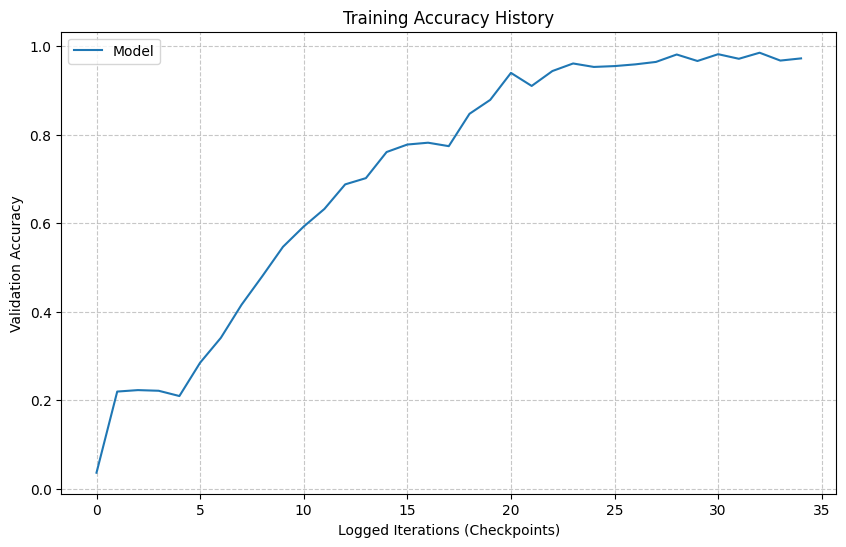

In [86]:
plot_training_curves([acc_h1],  ['Model'])

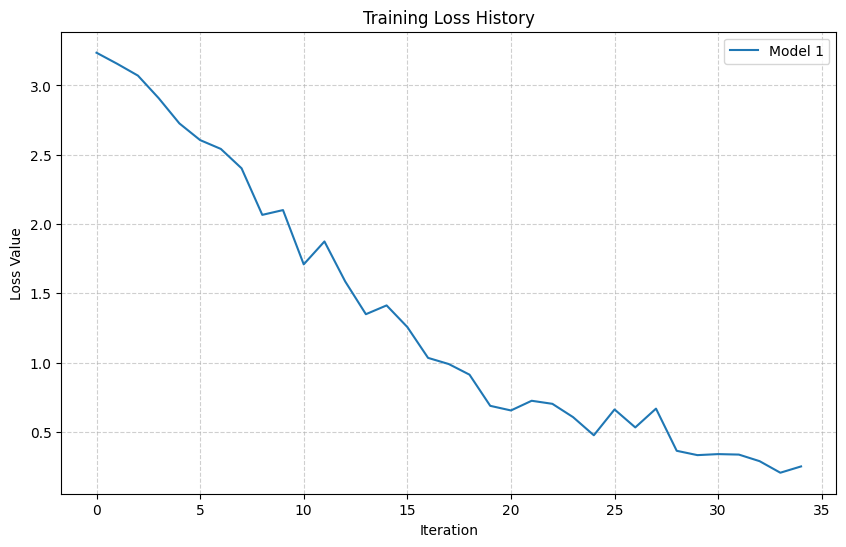

In [87]:
plot_loss_curve([loss_h1], ['Model 1'])

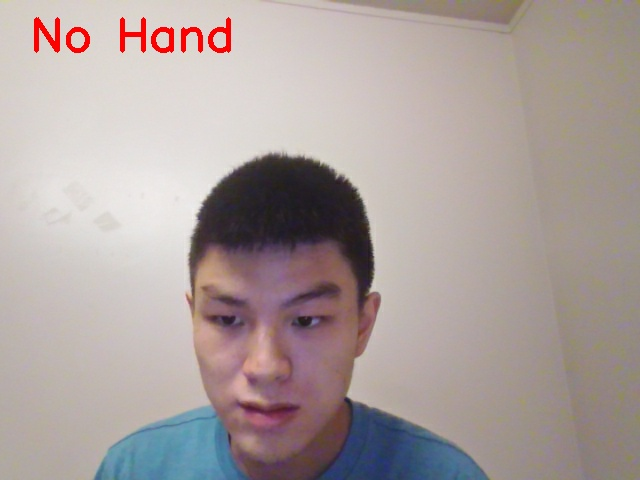

Stopped.


In [30]:

LETTERS = ['a','b','c','d','e','f','g','h','i', 'j', 'k','l','m',
           'n','o','p','q','r','s','t','u','v','x','y']

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_hands=1
)
detector = vision.HandLandmarker.create_from_options(options)

# ===============================
# WEBCAM SETUP
# ===============================
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("ERROR: Cannot open webcam")
else:
    print("Webcam started — Stop the cell to quit")

# ===============================
# MAIN LOOP
# ===============================
try:
    while True:
        ret, frame = cap.read()
        if not ret: break

        frame = cv2.flip(frame, 1)
        h, w = frame.shape[:2]

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, 
                            data=np.ascontiguousarray(rgb))

        result = detector.detect(mp_image)

        if result.hand_landmarks:
            dist_vector = get_dist_1d_vector(result)
            
            if dist_vector is not None:
                # 1. Create tensor and reshape to 21x21 to get upper triangle
                features_grid = torch.tensor(dist_vector, dtype=torch.float32).view(21, 21)
                row_idx, col_idx = torch.triu_indices(row=21, col=21, offset=1)
                final_features = features_grid[row_idx, col_idx] # This is 210
                
                # 2. IMPORTANT: Reshape for Conv1d -> (Batch=1, Channels=1, Length=210)
                input_tensor = final_features.view(1, 1, 210)
                
                with torch.no_grad():
                    output = model(input_tensor)
                    # output[0] is usually enough, but let's be safe
                    probs = torch.softmax(output.squeeze(), dim=0).numpy()

                idx = np.argmax(probs)
                letter = LETTERS[idx].upper()
                conf = probs[idx]

                # Draw landmarks
                for lm in result.hand_landmarks[0]:
                    px, py = int(lm.x * w), int(lm.y * h)
                    cv2.circle(frame, (px, py), 5, (0, 255, 0), -1)

                cv2.putText(frame, f"{letter} ({conf:.2f})", (30, 50),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 3)
        else:
            cv2.putText(frame, "No Hand", (30, 50),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 3)

        # Display in Notebook
        _, buffer = cv2.imencode('.jpg', frame)
        clear_output(wait=True)
        display(Image(data=buffer))

except KeyboardInterrupt:
    print("Stopped.")
finally:
    cap.release()

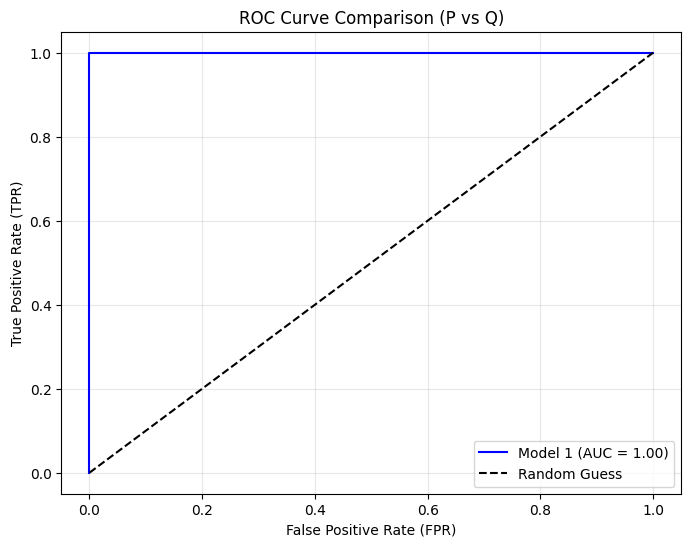

In [89]:
def get_binary_subset(model, loader, class_p=15, class_q=16):
    probs_all, labels_all = get_probs_and_labels(model, loader)
    probs_all = np.array(probs_all)
    labels_all = np.array(labels_all)
    mask = (labels_all == class_p) | (labels_all == class_q)
    y_true_raw = labels_all[mask]
    y_score_raw = probs_all[mask]
    y_true = np.where(y_true_raw == class_p, 0, 1)
    if y_score_raw.ndim > 1:
        p_probs = y_score_raw[:, class_p]
        q_probs = y_score_raw[:, class_q]
        y_score = q_probs / (p_probs + q_probs)
    else:
        y_score = y_score_raw
    return y_true, y_score

labels1, probs1 = get_binary_subset(model, loader_test)
probs1 = 1 - probs1
fpr1, tpr1, _ = roc_curve(labels1, probs1)
roc_auc1 = auc(fpr1, tpr1)
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f'Model 1 (AUC = {roc_auc1:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison (P vs Q)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()